In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

x,_ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
transformation = [[.6,-.6],[-.4,.8]]
x_stretched = np.dot(x,transformation)
x_scaled=StandardScaler().fit_transform(x_stretched)

gmm=GaussianMixture(n_components=3,covariance_type='full',random_state=42,init_params='k-means++',verbose=1)
gmm.fit(x_scaled)


Initialization 0
Initialization converged.


,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'k-means++'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [11]:
soft_probs = gmm.predict_proba(x_scaled[:3])
print("--- Soft Probabilities Example ---")
for idx, prob in enumerate(soft_probs):
    print(f"Point {idx} -> Cluster 0: {prob[0]*100:.1f}%, Cluster 1: {prob[1]*100:.1f}%, Cluster 2: {prob[2]*100:.1f}%")
    
densities = gmm.score_samples(x_scaled)
density_threshold = np.percentile(densities,4)
anomalies_mask = densities < density_threshold

--- Soft Probabilities Example ---
Point 0 -> Cluster 0: 0.0%, Cluster 1: 0.0%, Cluster 2: 100.0%
Point 1 -> Cluster 0: 0.0%, Cluster 1: 0.0%, Cluster 2: 100.0%
Point 2 -> Cluster 0: 100.0%, Cluster 1: 0.0%, Cluster 2: 0.0%


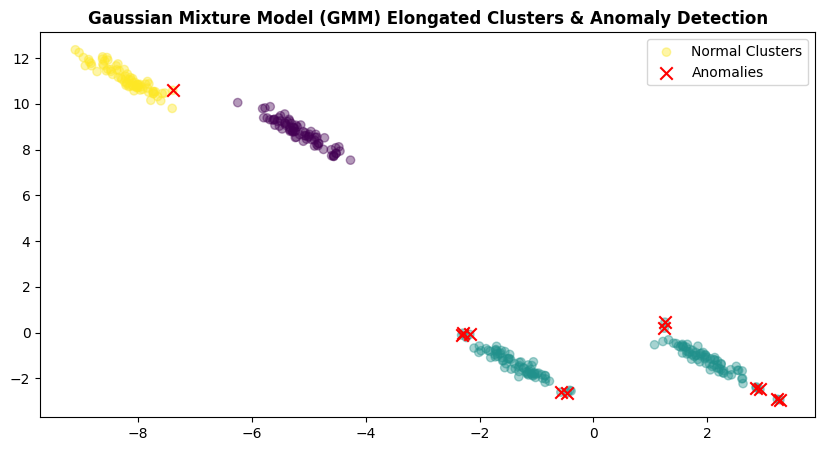

In [12]:
labels = gmm.predict(x_scaled)

plt.figure(figsize=(10, 5))
# Plot standard cluster groupings
plt.scatter(x_stretched[:, 0], x_stretched[:, 1], c=labels, cmap='viridis', alpha=0.4, label="Normal Clusters")
# Overlay isolated structural anomalies in red
plt.scatter(x_stretched[anomalies_mask, 0], x_stretched[anomalies_mask, 1], c='red', marker='x', s=80, label="Anomalies")

plt.title("Gaussian Mixture Model (GMM) Elongated Clusters & Anomaly Detection", fontsize=12, fontweight='bold')
plt.legend()
plt.show()